In [30]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Reshape
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [31]:

# Parameters
img_height, img_width = 64, 64  # Resize images to these dimensions
batch_size = 32
epochs = 27
num_classes = 5  # Adjust based on your dataset's number of classes


In [32]:

# Data Augmentation and Preprocessing
train_data_dir = 'dataset/train'
test_data_dir = 'dataset/test'


In [33]:

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [34]:

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 5000 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.


In [35]:

# Model Definition
model = Sequential()

# Convolutional layers to extract features
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Reshape the feature maps to treat them as sequences
model.add(Reshape((36, 128)))  # Reshape to (sequence_length, features)

# Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(64, return_sequences=False)))

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model Summary
model.summary()


Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 62, 62, 32)        896       
_________________________________________________________________
max_pooling2d_12 (MaxPooling (None, 31, 31, 32)        0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 29, 29, 64)        18496     
_________________________________________________________________
max_pooling2d_13 (MaxPooling (None, 14, 14, 64)        0         
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 12, 12, 128)       73856     
_________________________________________________________________
max_pooling2d_14 (MaxPooling (None, 6, 6, 128)         0         
_________________________________________________________________
reshape_4 (Reshape)          (None, 36, 128)          

In [36]:

# Training the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.samples // batch_size
)


Epoch 1/27
156/156 [==============================] - 29s 184ms/step - loss: 1.1646 - accuracy: 0.5169 - val_loss: 0.9045 - val_accuracy: 0.6569
Epoch 2/27
156/156 [==============================] - 27s 170ms/step - loss: 0.8454 - accuracy: 0.6645 - val_loss: 0.8320 - val_accuracy: 0.6529
Epoch 3/27
156/156 [==============================] - 26s 167ms/step - loss: 0.7306 - accuracy: 0.7252 - val_loss: 0.6239 - val_accuracy: 0.7595
Epoch 4/27
156/156 [==============================] - 26s 166ms/step - loss: 0.6244 - accuracy: 0.7633 - val_loss: 0.5535 - val_accuracy: 0.7989
Epoch 5/27
156/156 [==============================] - 26s 167ms/step - loss: 0.5683 - accuracy: 0.7878 - val_loss: 0.4676 - val_accuracy: 0.8274
Epoch 6/27
156/156 [==============================] - 26s 169ms/step - loss: 0.5032 - accuracy: 0.8128 - val_loss: 0.4676 - val_accuracy: 0.8254
Epoch 7/27
156/156 [==============================] - 27s 170ms/step - loss: 0.4570 - accuracy: 0.8305 - val_loss: 0.4117 - val_ac

In [37]:

# Plot accuracy and loss graphs
def plot_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()


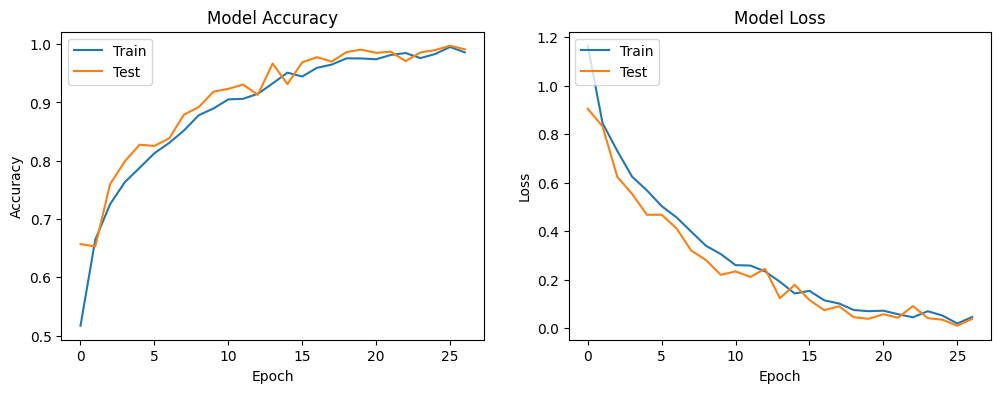

In [38]:

# Display accuracy and loss plots
plot_history(history)

In [39]:
model.save("wild1.h5")